# Analysis: Post-Inclusion Impact on MSCI World Index Additions

**Goal**: Quantify the stock price impact *after* the inclusion of a stock into the MSCI World Index.

**Method**: Factor-Adjusted Event Study (Fama-French 5-Factor Model).

## 1. Environment Setup
Importing necessary libraries for data manipulation (pandas, numpy), statistical modeling (statsmodels), and visualization (matplotlib, seaborn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import timedelta
from pathlib import Path

## 2. Load Risk Factors (Fama-French 5-Factor Model)
We use the daily Fama-French 5-factor model to control for systematic risk.
*   **Factors**: Market (Mkt-RF), Size (SMB), Value (HML), Profitability (RMW), Investment (CMA).
*   **Scaling**: Data is divided by 100 to convert from percent to decimal, aligning with our stock return format.

In [2]:
FF5 = pd.read_csv('F-F_Research_Data_5_Factors_2x3_daily.csv')
FF5['Date'] = pd.to_datetime(FF5['Date'], format="%Y%m%d")
FF5 = FF5.set_index('Date').dropna()
FF5 /= 100
FF5.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-01,-0.0067,0.0000,-0.0034,-0.0001,0.0016,0.0001
1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001
1963-07-08,-0.0063,0.0004,-0.0018,-0.0029,0.0014,0.0001


## 3. Load Event List (MSCI World Additions)
Loading the list of companies added to the MSCI World Index (2020-2025).
*   **Announcement Date**: When MSCI publicly confirms the addition.
*   **Effective Date**: When the addition actually occurs (funds must trade by close).

**Note**: For this analysis, we focus on the **Effective Date** as our event day ($t=0$).

In [3]:
adds_MSCI = pd.read_csv('msci_additions.csv')
adds_MSCI['Announcement Date'] = pd.to_datetime(adds_MSCI['Announcement Date'])
adds_MSCI['Effective Date'] = pd.to_datetime(adds_MSCI['Effective Date'])
adds_MSCI.head()

,Ticker,Company Name,Announcement Date,Effective Date
0,NBIS,Nebius Group,2025-11-06,2025-11-25
1,CWV,CoreWeave (Private/New),2025-11-06,2025-11-25
2,INSM,Insmed,2025-11-06,2025-11-25
3,RKLB,Rocket Lab,2025-08-11,2025-08-29
4,SOFI,SoFi Technologies,2025-08-11,2025-08-29


## 4. Load Cached Stock Prices
Loading daily data for all target tickers (sourced from Polygon via `data_collection.ipynb`).
These provide the raw `Return` series for our analysis.

In [4]:
prices_path = Path('polygon_prices.parquet')
if prices_path.exists():
    polygon_prices = pd.read_parquet(prices_path)
    print(f"Loaded polygon_prices from {prices_path} (rows={len(polygon_prices)})")
else:
    raise FileNotFoundError("polygon_prices.parquet not found. Run data_collection.ipynb first.")

polygon_prices.head()

Loaded polygon_prices from polygon_prices.parquet (rows=11842)


Volume       vw   Open  Close   High    Low  \
Ticker Date                                                                  
NBIS   2024-11-06 05:00:00  4144060.0  18.9280  19.93  19.30  19.93  17.50   
       2024-11-07 05:00:00  2570089.0  20.2407  19.08  20.68  20.90  19.08   
       2024-11-08 05:00:00  2356030.0  20.0703  20.98  19.92  21.00  19.50   
       2024-11-11 05:00:00  2907456.0  20.4884  19.80  20.94  21.30  19.18   
       2024-11-12 05:00:00  2125500.0  19.9555  20.50  19.60  20.93  19.50   

                                        t      n    Return  
Ticker Date                                                 
NBIS   2024-11-06 05:00:00  1730869200000  21276       NaN  
       2024-11-07 05:00:00  1730955600000  17017  0.071503  
       2024-11-08 05:00:00  1731042000000  15403 -0.036750  
       2024-11-11 05:00:00  1731301200000  23707  0.051205  
       2024-11-12 05:00:00  1731387600000  17776 -0.063992

## 5. Data Processing & Window Setup
We merge stock returns with factor data and compute **Excess Returns**:
$$ R_{excess} = R_{stock} - R_{risk\_free} $$

We also define our study windows relative to the **Effective Date** ($t=0$):
1.  **Estimation Window**: Days -250 to -81 (relative to Effective Date). Used to fit the factor model. We end at -81 to ensure we don't capture the run-up period (which typically starts around -60 days).
2.  **Post-Event Window**: Days 0 to 60. The period *after* inclusion where we check for price impact/drift.

In [5]:
returns = (
    polygon_prices[['Return']]
    .dropna()
    .reset_index()
    .assign(Date=lambda df: pd.to_datetime(df['Date']).dt.tz_localize(None).dt.normalize())
)

ff5_norm = FF5.copy()
ff5_norm.index = pd.to_datetime(ff5_norm.index).tz_localize(None).normalize()

returns = (
    returns
    .merge(ff5_norm, left_on='Date', right_index=True, how='inner')
    .set_index(['Ticker', 'Date'])
    .sort_index()
)

returns['Excess'] = returns['Return'] - returns['RF']

factor_cols = [c for c in FF5.columns if c != 'RF']
# Estimation window relative to Effective Date. Ends well before Announcement/Effective to be clean.
est_window = (-200, -81)
# Look at 60 days (approx 3 months) after inclusion
days_after_inclusion = range(0, 61)

## 6. Event Study: Calculating Abnormal Returns (AR)

For each stock, we:
1.  **Fit Model**: Regress excess returns on the FF5 factors during the *Estimation Window*.
2.  **Predict**: Use the fitted $\beta$s to predict expected return in the *Post-Event Window*.
3.  **Abnormal Return (AR)**: Subtract expected from actual.
4.  **Cumulative AR (CAR)**: Aggregate ARs from day 0 (Effective) to day $k$.
    $$ CAR_k = \sum_{t=0}^{k} AR_t $$

In [6]:
car_by_k = {k: [] for k in days_after_inclusion}

for _, row in adds_MSCI.iterrows():
    tkr = row['Ticker']
    # Use Effective Date as the event anchor
    eff = row['Effective Date']
    
    if tkr not in returns.index.get_level_values('Ticker'):
        continue

    sub = returns.xs(tkr, level='Ticker').sort_index()
    # Calculate relative day index centered on Effective Date
    # If date > effective, rel > 0
    rel = pd.Series(range(len(sub)), index=sub.index) - sub.index.searchsorted(eff)
    sub['rel'] = sub.index.map(rel)

    est = sub[(sub['rel'] >= est_window[0]) & (sub['rel'] <= est_window[1])].dropna(subset=['Excess'])

    # Require full estimation window coverage
    if len(est) < (est_window[1] - est_window[0]) or est[factor_cols].isnull().any().any():
        continue

    model = sm.OLS(est['Excess'], sm.add_constant(est[factor_cols])).fit()
    sub = sub.dropna(subset=factor_cols + ['Excess'])
    sub['AR'] = sub['Excess'] - model.predict(sm.add_constant(sub[factor_cols]))

    for k in days_after_inclusion:
        # Calculate CAR from day 0 to day k
        car = (sub.loc[(sub['rel'] >= 0) & (sub['rel'] <= k), 'AR']).sum()
        # Only add if we have data for this window
        # Check if we actually covered up to day k (approx)
        # Or just sum whatever is available? Better to be strict or ensure data exists.
        # Let's just check if the result is not NaN and not 0 if empty.
        if not np.isnan(car):
            car_by_k[k].append(car)

## 7. Aggregating Results
We average the CARs across all events for each day $k$ after inclusion.

In [7]:
car_df = (
    pd.DataFrame([
        {
            'days_post_inclusion': k,
            'mean_CAR': np.mean(v),
            'n_events': len(v),
            'tstat': (np.mean(v) / (np.std(v, ddof=1) / np.sqrt(len(v)))) if len(v) > 1 and np.std(v, ddof=1) > 0 else np.nan,
        }
        for k, v in car_by_k.items() if len(v) > 0
    ])
    .sort_values('days_post_inclusion')
)

car_df.head()

,days_post_inclusion,mean_CAR,n_events,tstat
0,0,-0.004265,40,-0.710398
1,1,-0.004182,40,-0.697045
2,2,-0.003905,40,-0.651593
3,3,-0.003139,40,-0.519576
4,4,-0.003216,40,-0.533070


## 8. Visualization
Plotting Mean CAR vs. Days Post-Inclusion.
*   **X-axis**: Days after effective date ($t=0$).
*   **Y-axis**: Mean Cumulative Abnormal Return.

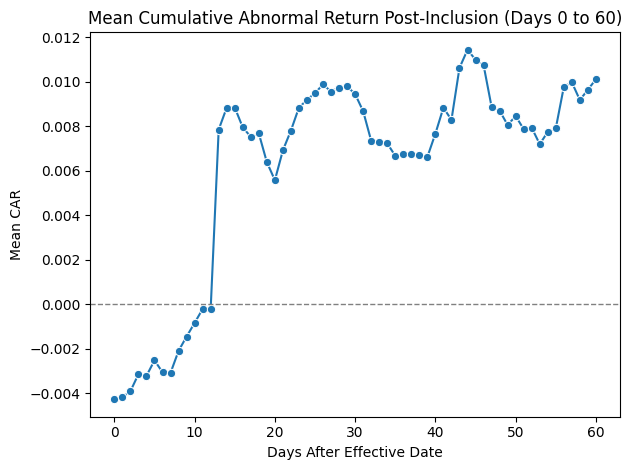

Day +1: CAR = -0.0042, t-stat = -0.70, n = 40
Day +5: CAR = -0.0025, t-stat = -0.41, n = 40
Day +10: CAR = -0.0008, t-stat = -0.12, n = 40
Day +20: CAR = 0.0056, t-stat = 0.50, n = 40
Day +60: CAR = 0.0101, t-stat = 0.66, n = 40


In [8]:
if not car_df.empty:
    sns.lineplot(data=car_df, x='days_post_inclusion', y='mean_CAR', marker='o')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title('Mean Cumulative Abnormal Return Post-Inclusion (Days 0 to 60)')
    plt.xlabel('Days After Effective Date')
    plt.ylabel('Mean CAR')
    plt.tight_layout()
    plt.show()
    
    # Print some stats for specific horizons
    for horizon in [1, 5, 10, 20, 60]:
        row = car_df[car_df['days_post_inclusion'] == horizon]
        if not row.empty:
            print(f"Day +{horizon}: CAR = {row['mean_CAR'].values[0]:.4f}, t-stat = {row['tstat'].values[0]:.2f}, n = {row['n_events'].values[0]}")
else:
    print("No CAR results generated.")

## 9. Conclusion
This chart shows the drift of stock prices after they have been added to the index. 
*   Positive drift might indicate continued buying pressure from trackers or momentum.
*   Reversal (negative slope) might indicate that the "inclusion premium" is fading.